# Determining the Optimal Number of Topics

A major drawback of most topic analysis models is their requirement that the user specify the number of topics prior to runtime. We can normally only guess which number is optimal. Data scientists therefore typically write a routine that runs with different numbers of topics, then plot the outcomes in terms of coherence (the degree to which high-scoring terms in a topic co-occur throughout the corpus) and Jaccard index (the similarity between different sets). The below code is from [this StackExchange solution](https://stackoverflow.com/a/64370066/920239).

In [1]:
import csv,pyLDAvis.gensim_models
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from copy import copy,deepcopy
from bs4 import BeautifulSoup
from pprint import pprint
from gensim import corpora
from gensim.models import LdaModel,CoherenceModel
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'(?:\w|\d)+')

In [2]:
data = dict()
_csv_path = Path.cwd().parent / 'misc' / 'scholarship.csv'
with open(_csv_path) as csv_file:
    csv_reader = csv.DictReader(csv_file, delimiter=',')

    for row in csv_reader:
        entry = dict()
        ref = row['author'].split(',')[0].split(' ')[0] + row['year'].replace('&ndash;', '_')
        if ref in data:
            ref = ref + 'a'
        soup = BeautifulSoup(row['abstract'], 'html.parser')
        entry['abstract'] = tokenizer.tokenize(soup.get_text().lower())
        entry['tags'] = row['tags'].split(',')
        if len(entry['abstract']) > 0:
            data[ref] = entry

In [3]:
corpus = []
for k,v in data.items():
    corpus.append(v['abstract'])
dictionary = corpora.Dictionary(corpus)
dictionary.filter_extremes(no_below=10, no_above=0.15)
dtmatrix = [dictionary.doc2bow(doc) for doc in corpus]

Evaluation code starts here:

In [4]:
num_topics = range(1,16)
num_keywords = 15

LDA_models = {}
LDA_topics = {}
for i in num_topics:
    LDA_models[i] = LdaModel(corpus=dtmatrix,
                             id2word=dictionary,
                             num_topics=i,
                             update_every=1,
                             chunksize=len(dtmatrix),
                             passes=20,
                             alpha='auto',
                             random_state=42)

    shown_topics = LDA_models[i].show_topics(num_topics=i, 
                                             num_words=num_keywords,
                                             formatted=False)
    LDA_topics[i] = [[word[0] for word in topic[1]] for topic in shown_topics]

In [5]:
def jaccard_similarity(topic_1, topic_2):
    """
    Derives the Jaccard similarity of two topics

    Jaccard similarity:
    - A statistic used for comparing the similarity and diversity of sample sets
    - J(A,B) = (A ∩ B)/(A ∪ B)
    - Goal is low Jaccard scores for coverage of the diverse elements
    """
    intersection = set(topic_1).intersection(set(topic_2))
    union = set(topic_1).union(set(topic_2))
                    
    return float(len(intersection))/float(len(union))

In [6]:
LDA_stability = {}
for i in range(0, len(num_topics)-1):
    jaccard_sims = []
    for t1, topic1 in enumerate(LDA_topics[num_topics[i]]): # pylint: disable=unused-variable
        sims = []
        for t2, topic2 in enumerate(LDA_topics[num_topics[i+1]]): # pylint: disable=unused-variable
            sims.append(jaccard_similarity(topic1, topic2))    
        
        jaccard_sims.append(sims)    
    
    LDA_stability[num_topics[i]] = jaccard_sims
                
mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics[:-1]]

In [7]:
coherences = [CoherenceModel(model=LDA_models[i], texts=corpus, dictionary=dictionary, coherence='c_v').get_coherence()\
              for i in num_topics[:-1]]

In [8]:
coh_sta_diffs = [coherences[i] - mean_stabilities[i] for i in range(num_keywords)[:-1]] # limit topic numbers to the number of keywords
coh_sta_max = max(coh_sta_diffs)
coh_sta_max_idxs = [i for i, j in enumerate(coh_sta_diffs) if j == coh_sta_max]
ideal_topic_num_index = coh_sta_max_idxs[0] # choose less topics in case there's more than one max
ideal_topic_num = num_topics[ideal_topic_num_index]

In [9]:
coherences

[0.24698635676610126,
 0.302992559371865,
 0.3807483966047453,
 0.41971914747650085,
 0.4387517168847448,
 0.42694912194429363,
 0.48692611021029747,
 0.48546422125238947,
 0.5202811934119714,
 0.5360676603989473,
 0.4831723862533625,
 0.5159439896346267,
 0.4870987533191856,
 0.5035153625886652]

In [10]:
mean_stabilities

[0.3068181818181818,
 0.24572649572649574,
 0.19083652618135374,
 0.15846726756239105,
 0.1125991280149495,
 0.08960475470716592,
 0.10188801246451394,
 0.0866476300975963,
 0.08766913882701576,
 0.07760992888860105,
 0.0711791792554333,
 0.06144791115101565,
 0.06330534694525031,
 0.05750564788530436]

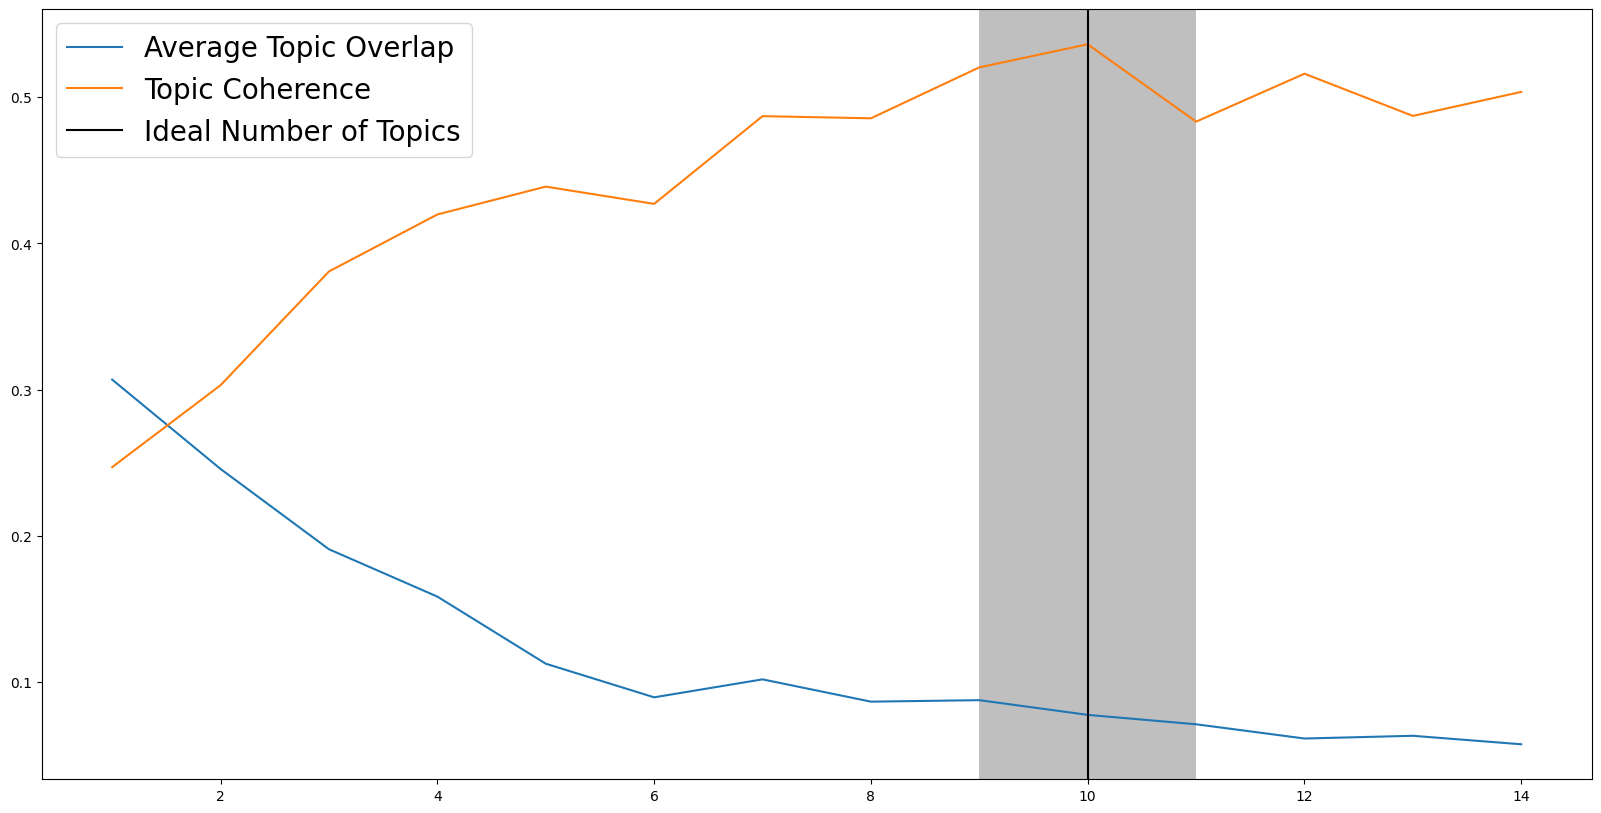

In [11]:
plt.figure(figsize=(20,10))
ax = plt.plot(pd.DataFrame(num_topics[:-1]).values, pd.DataFrame(mean_stabilities).values, label='Average Topic Overlap')
ax = plt.plot(pd.DataFrame(num_topics[:-1]).values, pd.DataFrame(coherences).values, label='Topic Coherence')

plt.axvline(x=ideal_topic_num, label='Ideal Number of Topics', color='black')
plt.axvspan(xmin=ideal_topic_num - 1, xmax=ideal_topic_num + 1, alpha=0.5, facecolor='grey')

plt.legend(fontsize=20)
plt.show()